# Modèle A — Résultats finaux (étapes A.5 / A.6 / A.7)

**Modèle retenu** : XGBoost réglé avec Optuna (`ml/src/model_a/tune.py`), réentraîné sur train + validation
(59 812 annonces), évalué **une seule fois** sur le jeu de test (10 556 annonces jamais vues).

Ce notebook recharge le modèle sauvegardé (`ml/models/model_a/`) et recalcule tout sur le jeu de test :
les chiffres sont ceux du modèle réellement servi par l'API.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ML_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ML_DIR / "src" / "model_a"))
from features import Preparateur, charger, charger_modele, decouper, mesures

MODEL_DIR = ML_DIR / "models" / "model_a"
FIG_DIR = ML_DIR / "reports" / "figures"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

modele = charger_modele(MODEL_DIR)
prep = Preparateur.charger(MODEL_DIR / "preparateur.json")
fiche = json.loads((MODEL_DIR / "fiche_modele.json").read_text(encoding="utf-8"))
final = json.loads((ML_DIR / "reports" / "model_a_final.json").read_text(encoding="utf-8"))
comparaison = json.loads((ML_DIR / "reports" / "model_a_comparison.json").read_text(encoding="utf-8"))

_train, _val, test = decouper(charger())
X_test = prep.transform(test)
prix_reel = test["prix"].to_numpy()
prix_predit = np.exp(modele.predict(X_test))
print(f"Jeu de test : {len(test):,} annonces — taille du modèle : {(MODEL_DIR / 'xgboost.ubj.gz').stat().st_size / 1e6:.0f} Mo")

Jeu de test : 10,556 annonces — taille du modèle : 42 Mo


## 1. Réglage (Optuna, 40 essais)

Chaque essai : entraînement sur le train, MAE mesurée sur la validation, nombre d'arbres fixé par arrêt anticipé.

**Règle de choix** : le meilleur essai brut produisait un modèle de 80 Mo (1 642 arbres de profondeur 12).
Parmi les essais à moins de **0,1 %** de la meilleure MAE, on retient le **plus léger** (arbres × 2^profondeur) :
même précision, modèle deux fois plus petit, plus rapide à charger et à déployer.

In [2]:
o = final["optuna"]
pd.DataFrame([
    {"Essai": "meilleur (brut)", "Nom": o["meilleur_essai"]["nom"], "MAE validation (DH)": round(o["meilleur_essai"]["MAE_validation_DH"]),
     "Arbres": o["meilleur_essai"]["parametres"]["n_estimators"], "Profondeur": o["meilleur_essai"]["parametres"]["max_depth"]},
    {"Essai": "retenu", "Nom": o["essai_retenu"]["nom"], "MAE validation (DH)": round(o["essai_retenu"]["MAE_validation_DH"]),
     "Arbres": o["essai_retenu"]["parametres"]["n_estimators"], "Profondeur": o["essai_retenu"]["parametres"]["max_depth"]},
]).set_index("Essai")

,Nom,MAE validation (DH),Arbres,Profondeur
Essai,,,,
meilleur (brut),essai_33,12676,1642,12
retenu,essai_29,12680,724,12


In [3]:
pd.Series(o["essai_retenu"]["parametres"]).to_frame("Paramètres retenus")

,Paramètres retenus
reg_lambda,0.042601
max_cat_to_onehot,1.000000
min_child_weight,3.764772
max_depth,12.000000
subsample,0.907174
n_estimators,724.000000
learning_rate,0.020431
reg_alpha,0.009180
colsample_bytree,0.973233


## 2. Score final sur le jeu de test

In [4]:
m_final = mesures(prix_reel, prix_predit)
lignes = {
    "Médiane par groupe (validation)": next(r for r in comparaison["resultats"] if r["modele"] == "Médiane par groupe"),
    "XGBoost non réglé (test)": final["test_xgboost_non_regle"],
    "XGBoost réglé — FINAL (test)": m_final,
}
tableau = pd.DataFrame({nom: {"MAE (DH)": r["MAE_DH"], "Erreur médiane (DH)": r["erreur_mediane_DH"], "MAPE (%)": r["MAPE_pct"],
                              "R²": r["R2"], "À ±15 % (%)": r["part_a_moins_de_15pct"]} for nom, r in lignes.items()}).T
tableau.round({"MAE (DH)": 0, "Erreur médiane (DH)": 0, "MAPE (%)": 1, "R²": 3, "À ±15 % (%)": 1})

,MAE (DH),Erreur médiane (DH),MAPE (%),R²,À ±15 % (%)
Médiane par groupe (validation),24287.0,9004.0,19.6,0.705,66.0
XGBoost non réglé (test),12657.0,6406.0,12.2,0.935,79.5
XGBoost réglé — FINAL (test),11779.0,5813.0,10.8,0.939,80.9


*La médiane par groupe est mesurée sur la validation (étape A.4) : elle sert d'ordre de grandeur de référence.
Les deux XGBoost sont mesurés sur le même jeu de test.*

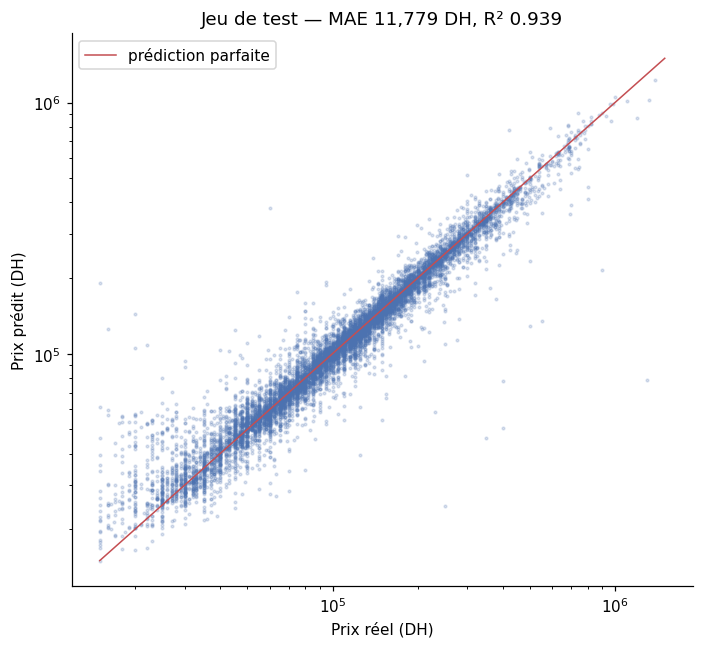

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(prix_reel, prix_predit, s=3, alpha=0.2, color="#4C72B0")
ax.plot([15_000, 1_500_000], [15_000, 1_500_000], color="#C44E52", lw=1, label="prédiction parfaite")
ax.set(xscale="log", yscale="log", xlabel="Prix réel (DH)", ylabel="Prix prédit (DH)",
       title=f"Jeu de test — MAE {m_final['MAE_DH']:,.0f} DH, R² {m_final['R2']:.3f}")
ax.legend(loc="upper left")
fig.tight_layout(); fig.savefig(FIG_DIR / "a6_reel_vs_predit.png"); plt.show()

## 3. Où le modèle se trompe-t-il ?

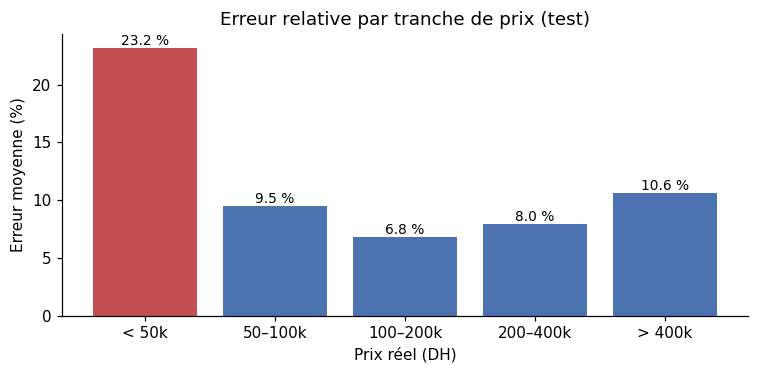

,annonces,MAE_DH,MAPE_pct
tranche,,,
< 50k,1866,6920.9,23.2
50–100k,3079,6988.6,9.5
100–200k,3765,9638.8,6.8
200–400k,1529,22236.7,8.0
> 400k,317,61880.4,10.6


In [6]:
erreur = np.abs(prix_predit - prix_reel)
tranches = pd.cut(prix_reel, [0, 50_000, 100_000, 200_000, 400_000, np.inf],
                  labels=["< 50k", "50–100k", "100–200k", "200–400k", "> 400k"])
par_tranche = (pd.DataFrame({"tranche": tranches, "err": erreur, "rel": erreur / prix_reel * 100})
               .groupby("tranche", observed=True).agg(annonces=("err", "size"), MAE_DH=("err", "mean"), MAPE_pct=("rel", "mean")))
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(par_tranche.index.astype(str), par_tranche["MAPE_pct"], color=["#C44E52"] + ["#4C72B0"] * 4)
for x, v in enumerate(par_tranche["MAPE_pct"]):
    ax.text(x, v, f"{v:.1f} %", ha="center", va="bottom", fontsize=9)
ax.set(xlabel="Prix réel (DH)", ylabel="Erreur moyenne (%)", title="Erreur relative par tranche de prix (test)")
fig.tight_layout(); fig.savefig(FIG_DIR / "a6_erreur_par_tranche.png"); plt.show()
par_tranche.round(1)

Le modèle est le plus précis sur le **milieu de gamme (100–200k DH, ~7 %)**, le segment le plus fréquent au Maroc.
Les voitures **à moins de 50 000 DH** sont les moins bien estimées (~23 %) : leur prix dépend surtout de l'état réel
(mécanique, carrosserie), que les annonces décrivent mal. Le service signale ces cas (« fiabilité réduite »).

In [7]:
pires = test.assign(prix_predit=prix_predit.round(-3), erreur_pct=(erreur / prix_reel * 100).round(0))
colonnes = ["marque", "modele", "annee", "kilometrage", "boite", "carburant", "etat", "prix", "prix_predit", "erreur_pct"]
pires.sort_values("erreur_pct", ascending=False)[colonnes].head(10)

,marque,modele,annee,kilometrage,boite,carburant,etat,prix,prix_predit,erreur_pct
7383,ford,ford | f350,2016,NaN,automatique,essence,tres_bon,15000,191000.0,1175.0
219,opel,opel | sintra,2023,22500.0,manuelle,essence,tres_bon,16000,125000.0,682.0
327,fiat,fiat | 126,2021,NaN,manuelle,diesel,bon,20000,144000.0,620.0
8415,alfa romeo,alfa romeo | 146,2023,17500.0,automatique,diesel,inconnu,60000,381000.0,535.0
5644,mercedes-benz,mercedes-benz | 300,1980,550000.0,manuelle,diesel,inconnu,20000,105000.0,426.0
8736,mercedes-benz,mercedes-benz | 410,1994,NaN,manuelle,diesel,excellent,22000,108000.0,390.0
4593,fiat,fiat | uno,1992,NaN,manuelle,essence,excellent,15000,61000.0,308.0
7988,fiat,fiat | uno,1997,NaN,manuelle,diesel,tres_bon,16000,60000.0,273.0
5243,fiat,fiat | uno,2000,NaN,manuelle,diesel,tres_bon,16000,57000.0,257.0
9309,ford,ford | ecosport,1987,165000.0,manuelle,essence,tres_bon,25000,80000.0,219.0


Les plus grosses erreurs révèlent surtout des **erreurs de saisie dans les annonces**, pas des erreurs du modèle :
une *Ford EcoSport de 1987* (le modèle est sorti en 2003), une *Fiat 126 de 2021* (production arrêtée en 2000),
une *Opel Sintra 2023* (arrêtée en 1999). L'année annoncée est fausse, donc l'âge aussi, et le modèle ne peut pas
retrouver le bon prix. Le reste concerne des véhicules rares ou très anciens (Mercedes 300 de 1980, Fiat Uno des années 90).

**Amélioration possible du nettoyage** : vérifier l'année contre les années de production de chaque modèle
(nécessite une table de référence marque / modèle / années).

## 4. Quelles variables comptent le plus ?

**Importance par permutation** : on mélange au hasard une variable dans le jeu de test et on mesure de combien l'erreur
moyenne augmente. Plus elle augmente, plus le modèle dépend de cette variable. Les 16 équipements sont mélangés ensemble.

*L'importance « gain » intégrée à XGBoost n'est pas utilisée : elle attribue 65 % à la boîte de vitesses, parce que
cette variable sert aux premières coupures des arbres ; elle surestime les variables utilisées tôt.*

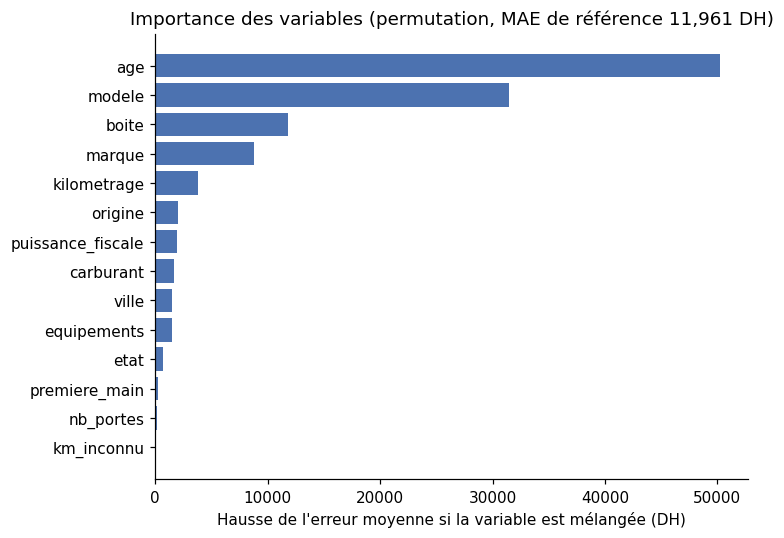

,Hausse MAE (DH)
age,50209.0
modele,31432.0
boite,11767.0
marque,8798.0
kilometrage,3843.0
origine,1996.0
puissance_fiscale,1983.0
carburant,1706.0
ville,1474.0
equipements,1462.0


In [8]:
rng = np.random.default_rng(42)
echantillon = X_test.sample(4000, random_state=42)
reel_ech = test.loc[echantillon.index, "prix"].to_numpy()
mae_ref = np.abs(np.exp(modele.predict(echantillon)) - reel_ech).mean()

groupes = {c: [c] for c in echantillon.columns if not c.startswith("eq_") and c != "nb_equipements"}
groupes["equipements"] = [c for c in echantillon.columns if c.startswith("eq_")] + ["nb_equipements"]

hausse = {}
for nom, cols in groupes.items():
    essais = []
    for _ in range(3):
        melange = echantillon.copy()
        ordre = rng.permutation(len(melange))
        for c in cols:  # set_axis garde le type (catégorie) de la colonne
            melange[c] = echantillon[c].iloc[ordre].set_axis(melange.index)
        essais.append(np.abs(np.exp(modele.predict(melange)) - reel_ech).mean() - mae_ref)
    hausse[nom] = np.mean(essais)

importance = pd.Series(hausse).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(importance.index, importance.values, color="#4C72B0")
ax.set(xlabel="Hausse de l'erreur moyenne si la variable est mélangée (DH)",
       title=f"Importance des variables (permutation, MAE de référence {mae_ref:,.0f} DH)")
fig.tight_layout(); fig.savefig(FIG_DIR / "a6_importance_variables.png"); plt.show()
importance.sort_values(ascending=False).round(0).to_frame("Hausse MAE (DH)")

## 5. Fourchettes de prix données par le service

In [9]:
f = fiche["fourchettes"]
print(f["methode"]); print(f"Couverture mesurée : {f['couverture_mesuree']:.1%}")
pd.DataFrame(f["tranches"]).assign(
    **{"écart bas": lambda d: ((d["facteur_bas"] - 1) * 100).round(0).astype(int).astype(str) + " %",
       "écart haut": lambda d: "+" + ((d["facteur_haut"] - 1) * 100).round(0).astype(int).astype(str) + " %"}
)[["prix_predit_min", "prix_predit_max", "écart bas", "écart haut", "annonces"]]

quantiles 10 % / 90 % du rapport prix réel / prix prédit sur le jeu de test, par tranche de prix prédit
Couverture mesurée : 80.0%


,prix_predit_min,prix_predit_max,écart bas,écart haut,annonces
0,0,50000.0,-26 %,+22 %,1620
1,50000,100000.0,-16 %,+16 %,3255
2,100000,200000.0,-10 %,+12 %,3840
3,200000,400000.0,-10 %,+14 %,1549
4,400000,NaN,-13 %,+17 %,292


## 6. Exemples d'estimation (service de prédiction)

In [10]:
sys.path.insert(0, str(ML_DIR / "service"))
from predictor import PredicteurPrix
from schemas import DemandeEstimation

predicteur = PredicteurPrix()
exemples = [
    dict(marque="dacia", modele="logan", annee=2019, kilometrage=90000, boite="manuelle", carburant="diesel", puissance_fiscale=6, ville="Casablanca"),
    dict(marque="renault", modele="clio", annee=2021, kilometrage=45000, boite="manuelle", carburant="diesel", ville="Rabat"),
    dict(marque="volkswagen", modele="tiguan", annee=2020, kilometrage=80000, boite="automatique", carburant="diesel", puissance_fiscale=8),
    dict(marque="mercedes-benz", modele="classe c", annee=2018, kilometrage=120000, boite="automatique", carburant="diesel", etat="excellent"),
    dict(marque="peugeot", modele="206", annee=2006, kilometrage=250000, boite="manuelle", carburant="essence"),
]
lignes = []
for e in exemples:
    r = predicteur.estimer(DemandeEstimation(**e))
    lignes.append({"véhicule": f"{e['marque']} {e['modele']} {e['annee']}", "km": e["kilometrage"], "prix estimé": r.prix_estime,
                   "fourchette": f"{r.fourchette.min:,} – {r.fourchette.max:,}", "fiabilité": r.fiabilite})
pd.DataFrame(lignes)

,véhicule,km,prix estimé,fourchette,fiabilité
0,dacia logan 2019,90000,84000,"70,000 – 97,000",normale
1,renault clio 2021,45000,129000,"116,000 – 144,000",normale
2,volkswagen tiguan 2020,80000,269000,"242,000 – 307,000",normale
3,mercedes-benz classe c 2018,120000,301000,"270,000 – 344,000",normale
4,peugeot 206 2006,250000,44000,"33,000 – 54,000",reduite


## Conclusion — Modèle A

| | |
|---|---|
| **Données** | 70 368 annonces réelles (MUCars-2024, 2024), nettoyées par 10 règles documentées |
| **Modèle** | XGBoost réglé (Optuna, 40 essais, suivi MLflow), 724 arbres, 42 Mo |
| **Précision (test)** | erreur moyenne ~11 800 DH (~11 %), R² 0,94, 81 % des annonces à ±15 % |
| **Gain** | ~2× plus précis que l'estimation par annonces comparables |
| **Mise en service** | FastAPI (`ml/service`, 15 tests) derrière l'API Node : `POST /vehicles/estimate` |

**Limites** : prix *demandés* (pas de transaction) ; niveau de prix 2024 (à réentraîner avec des annonces récentes) ;
précision faible sous 50 000 DH ; modèles rares (< 20 annonces) regroupés en « autre ».

**Perspectives** : collecter les prix de vente réels via l'app ; réentraînement périodique ; intégrer l'historique
d'entretien AUTO+ du véhicule (interventions) comme variable supplémentaire.